# 1. 单细胞数据加载, 准备AnnData

使用Wu 2021乳腺癌数据中的CID4535样本，输入包含原始count矩阵和细胞条码，另有基因名称与作者提供的细胞注释。

这个流程从数据读取开始，先进行质控和过滤，再做归一化与高变基因选择，之后进行降维和聚类，查看marker表达并展示作者注释，最后保存分析对象与结果。原始数据来自[GSE176078](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE176078)，样本集为[GSM5354538](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSM5354538)。


In [1]:
import pandas as pd
import scanpy as sc
import anndata as ad
from scipy.io import mmread
from pathlib import Path

PROJECT_DIR = Path("/Users/georicl/Documents/sc_sncell_github/")
DATA = PROJECT_DIR / "data/raw/wu2021_scrna_smoke/CID4535"

# 读取Matrix Market矩阵，转换为CSR稀疏矩阵
matrix = mmread(DATA / "count_matrix_sparse.mtx", spmatrix=True).tocsr()

barcodes = pd.read_csv(DATA / "count_matrix_barcodes.tsv", header=None, sep="\t")[0].astype(str)

genes = pd.read_csv(DATA / "count_matrix_genes.tsv", header=None, sep="\t")[0].astype(str)

metadata = pd.read_csv(DATA / "metadata.csv", index_col=0)
metadata = metadata.loc[barcodes].copy()
# 导入为Anndata
# 原始矩阵是genes x cells，所以要转置后读取，使得obs是细胞，var是基因
adata = ad.AnnData(
    X=matrix.T.tocsr(),
    obs=metadata,
    var=pd.DataFrame({"gene_symbol": genes.to_numpy()}, index=pd.Index(genes.to_numpy(), name="gene")),
)

adata.var_names_make_unique()
adata.X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 10443596 stored elements and shape (3961, 29733)>

通过导入AnnData，我们获得了一个包含obs × var（cells × genes）的矩阵。其中X保存表达量，obs保存每个细胞的信息，var保存每个基因的信息。这里obs中的一行是一个细胞，样本信息保存在orig.ident中。


In [2]:
import numpy as np
from IPython.display import display

# 统计细胞亚型的数量
display(adata.obs[["orig.ident", "subtype"]].value_counts())
adata.obs.head()

orig.ident  subtype
CID4535     ER+        3961
Name: count, dtype: int64

,orig.ident,nCount_RNA,nFeature_RNA,percent.mito,subtype,celltype_subset,celltype_minor,celltype_major
CID4535_AAACCTGTCGCGGATC,CID4535,3849,1532,2.572097,ER+,Endothelial ACKR1,Endothelial ACKR1,Endothelial
CID4535_AAAGCAAGTCCCGACA,CID4535,2254,1072,5.146406,ER+,Endothelial ACKR1,Endothelial ACKR1,Endothelial
CID4535_AAGGAGCCAAGCCGTC,CID4535,4848,1722,4.249175,ER+,Endothelial ACKR1,Endothelial ACKR1,Endothelial
CID4535_ACACCAACATCACCCT,CID4535,6125,2102,5.126531,ER+,Endothelial ACKR1,Endothelial ACKR1,Endothelial
CID4535_ACGGCCATCCAGGGCT,CID4535,1559,780,8.466966,ER+,Endothelial ACKR1,Endothelial ACKR1,Endothelial


# 2. 计算质量控制指标

## 2.1 标记线粒体基因

这里通过基因名称中的MT-前缀识别人类线粒体基因，并在var中添加mt这一列。后续使用这个标记计算每个细胞的线粒体表达占比，细胞和基因过滤在第3节处理。

In [3]:
# 标记线粒体基因，这一步不做过滤
adata.var["mt"] = adata.var["gene_symbol"].str.startswith("MT-")


In [4]:
print("线粒体基因数量：", adata.var["mt"].sum())

线粒体基因数量： 13


## 2.2 计算每个细胞的QC指标

基于原始count，我们计算每个细胞的总UMI数、检测到的基因数和线粒体UMI占比，然后查看整体分布与分位数。

- total_counts：每个细胞的总UMI数。
- n_genes_by_counts：每个细胞中count大于0的基因数。
- pct_counts_mt：线粒体基因UMI占总UMI的百分比。


In [5]:
# 基于原始的count计算质量控制指标
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)
qc_columns = ["total_counts", "n_genes_by_counts", "pct_counts_mt"]

# 查看每个细胞QC指标的分布和分位数
adata.obs[qc_columns].describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99])


,total_counts,n_genes_by_counts,pct_counts_mt
count,3961.000000,3961.000000,3961.000000
mean,13914.334007,2636.605908,7.473468
std,13057.361208,1625.640672,4.497347
min,261.000000,201.000000,0.429448
1%,307.600000,220.000000,0.870904
5%,740.000000,399.000000,1.634043
50%,8818.000000,2329.000000,6.970245
95%,37565.000000,5284.000000,16.645525
99%,53396.800000,6282.200000,18.917850
max,112916.000000,7887.000000,19.982602


## 2.3 核对作者提供的结果

作者的metadata中已经包含nCount_RNA和nFeature_RNA。我们将重新计算的结果与这两列逐细胞比较，检查矩阵和注释是否正确对应。

In [6]:
# 与原始作者提供的数据进行对比
pd.Series(
    {
        "UMI 数不一致的细胞数": (adata.obs["total_counts"] != adata.obs["nCount_RNA"]).sum(),
        "检测基因数不一致的细胞数": (adata.obs["n_genes_by_counts"] != adata.obs["nFeature_RNA"]).sum(),
    }
)

UMI 数不一致的细胞数    0
检测基因数不一致的细胞数    0
dtype: int64

## 2.4 绘制QC分布图

通过小提琴图查看三个指标的分布，再通过散点图查看UMI数、检测基因数与线粒体比例的关系。重点观察低UMI、低基因数的细胞，以及线粒体比例较高或UMI特别高的细胞。

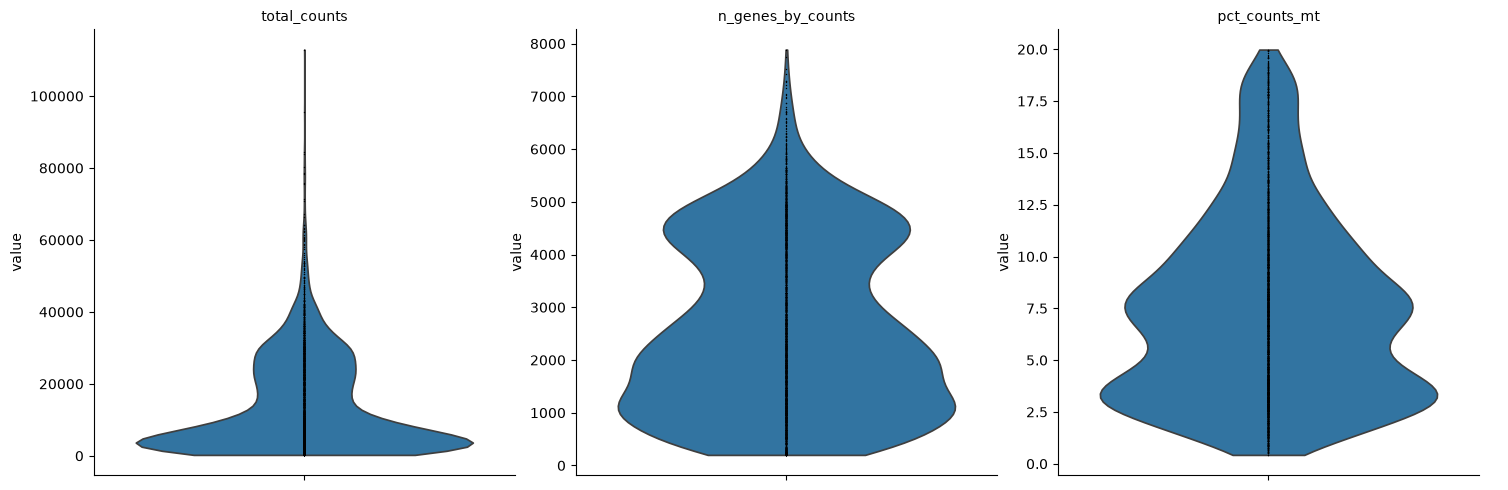

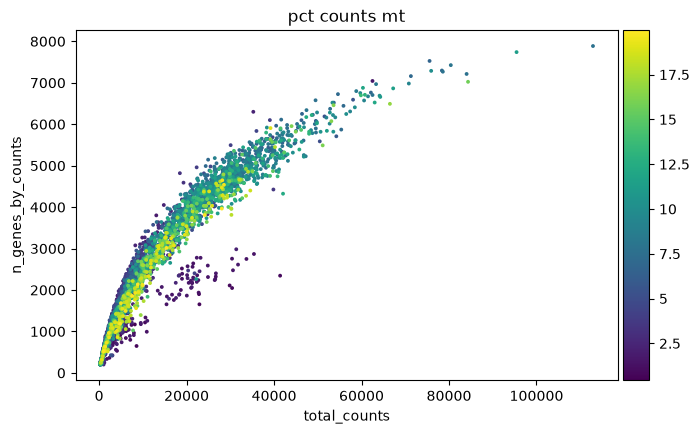

In [7]:
# 绘制QC分布图
# 查看三个指标的整体分布
sc.pl.violin(
    adata,
    keys=qc_columns,
    jitter=False,
    multi_panel=True,
)

# 查看测序深度、基因数与线粒体比例的关系
sc.pl.scatter(
    adata,
    x="total_counts",
    y="n_genes_by_counts",
    color="pct_counts_mt",
)

# 3. 设置过滤条件, 保留质控记录

## 3.1 根据分布设置参数

我们使用的是作者公开的处理后count矩阵，需要结合作者原有的过滤方式与当前QC分布，再决定是否进一步过滤。默认保留作者提供的细胞。

需要时，可以在原始count上逐样本使用Scanpy的Scrublet进行候选筛查，结合预期双细胞率、分数分布和不同谱系marker共同判断。

先填写参数和依据，再执行过滤。修改过滤参数时，重新运行本节以及后续所有步骤。

In [8]:
# 使用作者提供的细胞，所以这里没有任何改动， 但是要去掉细胞中完全不表达的基因
qc_params = {
    "min_genes": None,
    "max_genes": None,
    "min_counts": None,
    "max_counts": None,
    "max_pct_mt": None,
    "min_cells_per_gene": 1,
}


## 3.2 执行过滤并记录数量

这里保留原来的adata，另建adata_qc用于后续分析。每个过滤条件单独记录，最后取所有条件的交集。

过滤记录保留所有输入细胞的条码，后续可以追溯哪些细胞被保留、哪些细胞被排除。

In [9]:
qc_checks = pd.DataFrame(index=adata.obs_names)

# 获取参数和阈值
for param, column, direction in [
    ("min_genes", "n_genes_by_counts", "min"),
    ("max_genes", "n_genes_by_counts", "max"),
    ("min_counts", "total_counts", "min"),
    ("max_counts", "total_counts", "max"),
    ("max_pct_mt", "pct_counts_mt", "max"),
]:
    value = qc_params[param]
    if value is not None:
        qc_checks[param] = adata.obs[column] >= value if direction == "min" else adata.obs[column] <= value

keep_cells = qc_checks.all(axis=1)
if not keep_cells.any():
    raise ValueError("没有细胞通过过滤，请重新检查阈值。")

# 记录QC的barcode
qc_record = adata.obs[["orig.ident", *qc_columns]].join(qc_checks.add_prefix("pass_"))
qc_record["keep"] = keep_cells
adata_qc = adata[keep_cells].copy()
sc.pp.filter_genes(adata_qc, min_cells=qc_params["min_cells_per_gene"])
# 汇总最后QC前后结果的dataframe
filter_summary = pd.DataFrame(
    {
        "before": [adata.n_obs, adata.n_vars],
        "after": [adata_qc.n_obs, adata_qc.n_vars],
    },
    index=["cells", "genes"],
)
display(filter_summary)
display((~qc_checks).sum().rename("excluded_by_condition"))

,before,after
cells,3961,3961
genes,29733,22061


Series([], Name: excluded_by_condition, dtype: float64)

## 3.3 检查过滤对细胞组成的影响

通过作者提供的大类标签，查看不同细胞群的保留情况。返回QC图检查，后续仍要通过marker复核。

,before,after,retained_fraction
celltype_major,,,
Cancer Epithelial,2223,2223,1.0
PVL,592,592,1.0
T-cells,396,396,1.0
Myeloid,255,255,1.0
Endothelial,219,219,1.0
CAFs,102,102,1.0
Plasmablasts,96,96,1.0
B-cells,56,56,1.0
Normal Epithelial,22,22,1.0


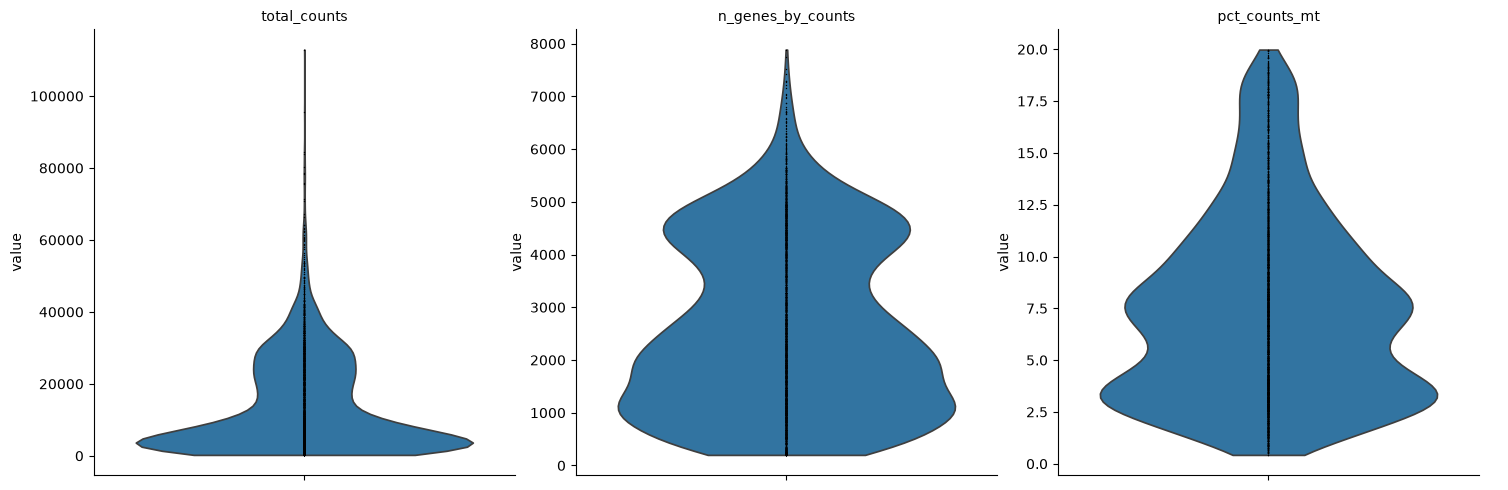

In [10]:
composition_qc = pd.DataFrame(
    {
        "before": adata.obs["celltype_major"].value_counts(),
        "after": adata_qc.obs["celltype_major"].value_counts(),
    }
).fillna(0)
composition_qc["retained_fraction"] = composition_qc["after"] / composition_qc["before"]
display(composition_qc)
sc.pl.violin(adata_qc, keys=qc_columns, jitter=False, multi_panel=True)

# 4. 保存count层, 进行归一化

过滤完成后，我们先将原始count保存在layers["counts"]中，再对X进行每细胞总量归一化和log1p转换。后续聚类和marker展示使用处理后的X，需要原始计数的方法使用counts层。

In [11]:
# 进行第一次归一化， 目标表达量调整到10000
adata_analysis = adata_qc.copy()  # 拷贝qc后的anndata
adata_analysis.layers["counts"] = adata_analysis.X.copy()
sc.pp.normalize_total(adata_analysis, target_sum=10000)
sc.pp.log1p(adata_analysis)
adata_analysis

AnnData object with n_obs × n_vars = 3961 × 22061
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'log1p'
    layers: None (.X), 'counts'

# 5. 选择高变基因

高变基因用于突出细胞间的表达差异，后续PCA主要基于这些基因计算。这里使用seurat方法，输入是已经归一化并log1p转换的X。

subset=False表示只添加高变基因标记，不删除其他基因。这样后续检查marker时，仍然可以查看全部保留基因。

高变基因数量： 3000


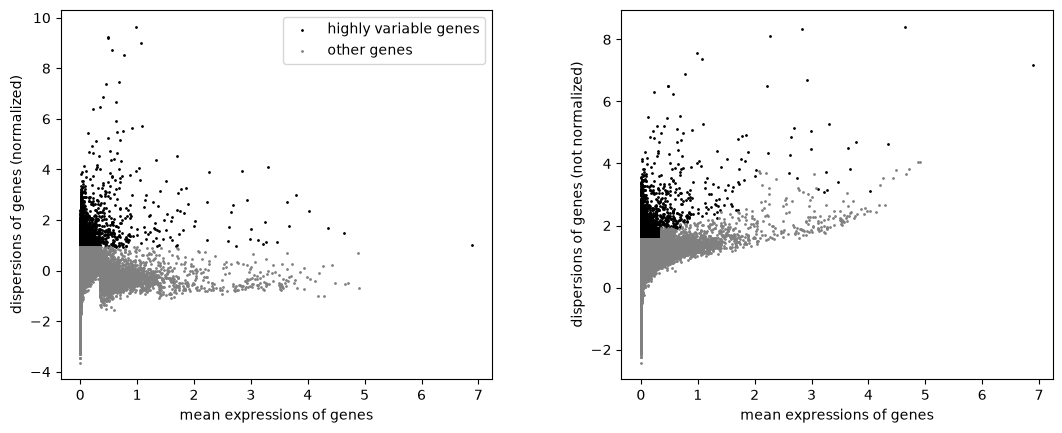

In [12]:
sc.pp.highly_variable_genes(
    adata_analysis,
    flavor="seurat",
    n_top_genes=3000,  # 取前3000个高变基因
    subset=False,
)
print("高变基因数量：", adata_analysis.var["highly_variable"].sum())
sc.pl.highly_variable_genes(adata_analysis)

# 6. PCA降维, 查看主成分

下面先计算最多50个主成分，再通过方差解释图和QC着色图检查主成分。邻居图起步使用前30个PC。


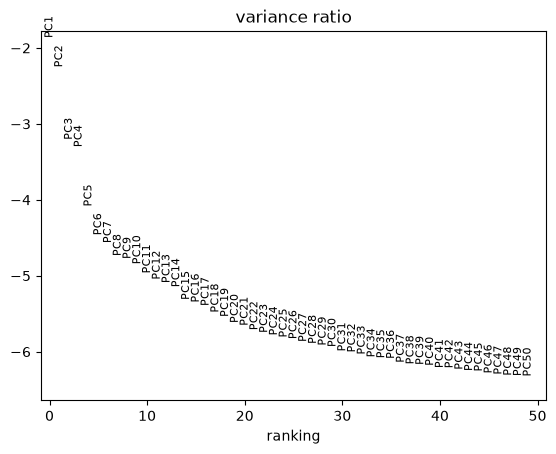

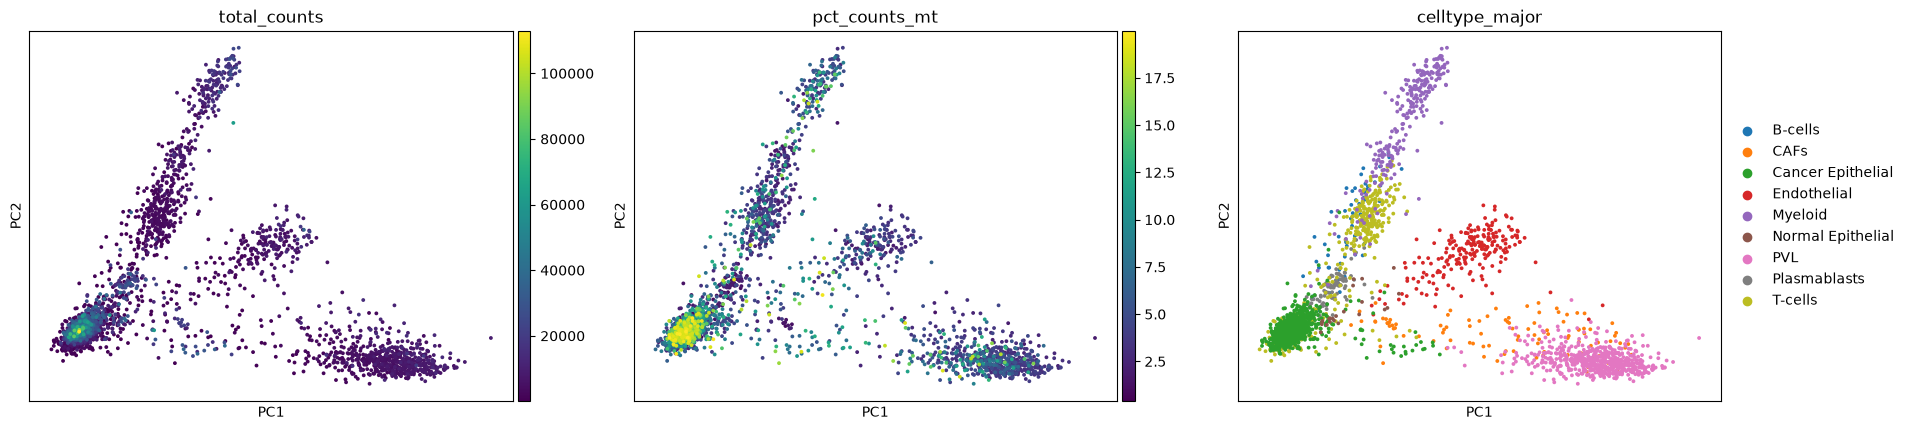

In [13]:
n_hvg = int(adata_analysis.var["highly_variable"].sum())
n_pcs = min(50, adata_analysis.n_obs - 1, n_hvg - 1)
if n_pcs < 2:
    raise ValueError("可用细胞或高变基因过少。")

# pca
sc.pp.pca(
    adata_analysis,
    n_comps=n_pcs,
    mask_var="highly_variable",
    zero_center=True,
    svd_solver="arpack",
    random_state=0,
)
sc.pl.pca_variance_ratio(adata_analysis, n_pcs=n_pcs, log=True)
sc.pl.pca(adata_analysis, color=["total_counts", "pct_counts_mt", "celltype_major"])

# 7. 构建邻居图, 进行聚类和UMAP展示

## 7.1 根据PCA构建邻居图

邻居图描述细胞在PCA空间中的相似关系，后续Leiden聚类与UMAP都使用这个图。n_neighbors控制每个细胞参考的邻居数量，n_pcs控制使用的主成分数量。修改这两个参数后，需要重新运行聚类与UMAP。

In [14]:
n_pcs_used = min(30, adata_analysis.obsm["X_pca"].shape[1])
n_neighbors_used = min(15, adata_analysis.n_obs - 1)
sc.pp.neighbors(
    adata_analysis,
    n_neighbors=n_neighbors_used,
    n_pcs=n_pcs_used,
    use_rep="X_pca",
    random_state=0,
)
print("本轮邻居图使用PC数：", n_pcs_used)
print("本轮邻居数：", n_neighbors_used)

本轮邻居图使用PC数： 30
本轮邻居数： 15


## 7.2 Leiden聚类

这里使用Leiden划分细胞群，结果保存在obs["leiden"]中。

In [15]:
sc.tl.leiden(
    adata_analysis,
    resolution=0.5,
    flavor="igraph",
    directed=False,
    n_iterations=2,
    random_state=0,
    key_added="leiden",
)
adata_analysis.obs["leiden"].value_counts().sort_index()

leiden
0     221
1     629
2      61
3     861
4     516
5      29
6     224
7      32
8     346
9      43
10    261
11    178
12     97
13    136
14    294
15     33
Name: count, dtype: int64

## 7.3 UMAP展示与质量检查

UMAP用于展示邻居图中的细胞关系，聚类仍然来自前面的邻居图。我们分别按聚类、作者标签和QC指标着色，检查分群是否受到测序深度或线粒体比例的明显影响。


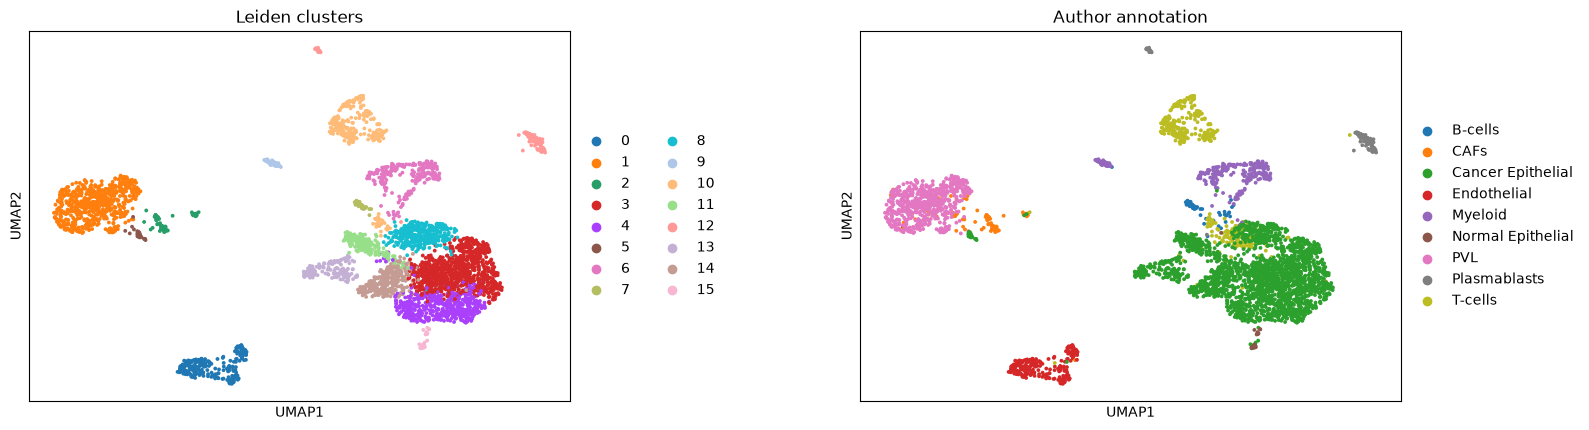

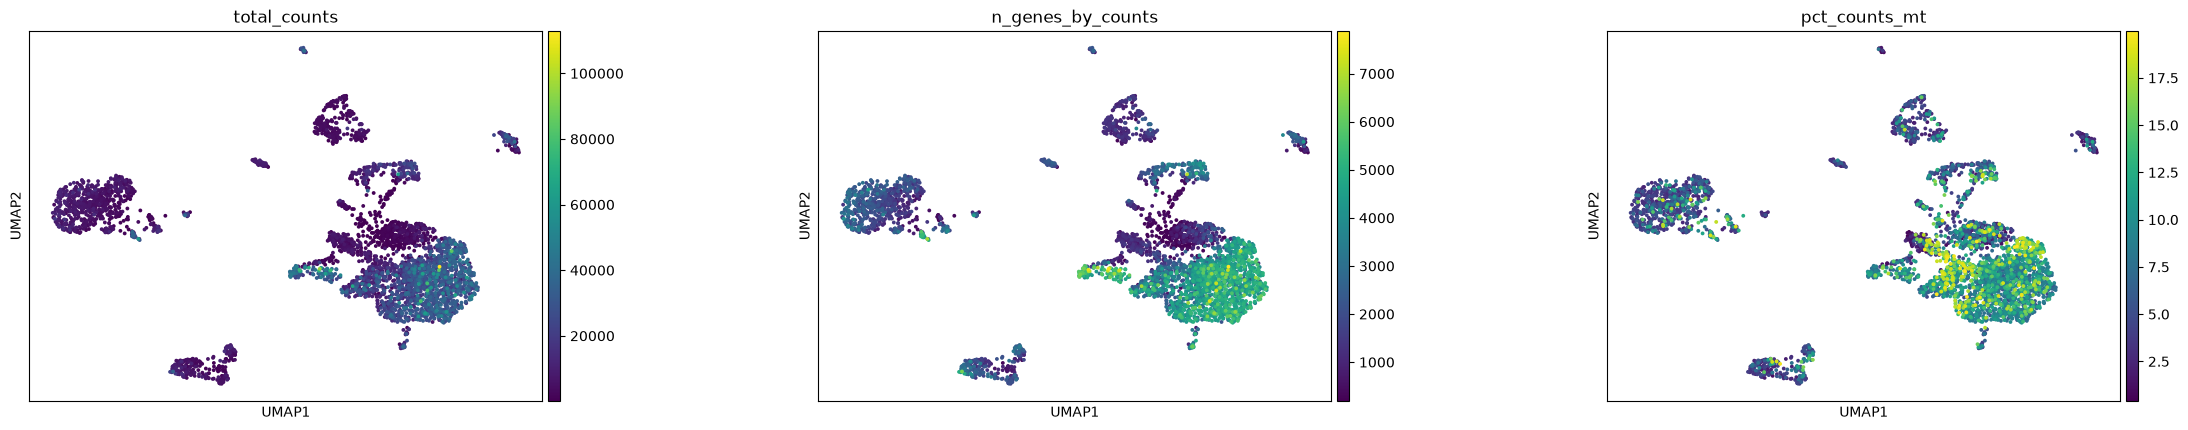

In [16]:
sc.tl.umap(
    adata_analysis,
    min_dist=0.5,
    random_state=0,
)
sc.pl.umap(adata_analysis, color=["leiden", "celltype_major"], title=["Leiden clusters", "Author annotation"], wspace=0.4)
sc.pl.umap(adata_analysis, color=qc_columns, wspace=0.4)

# 8. 查看作者注释群的marker表达特征

直接使用metadata中的作者大类注释celltype_major，比较每类与其余细胞的表达特征。使用log归一化后的全部保留基因、Wilcoxon检验，并输出表达比例与BH校正后的P值。

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,B-cells,CD74,10.323453,4.799645,5.520121e-25,1.217794e-20,0.964286,0.713956
1,B-cells,HLA-DRA,8.266754,4.225945,1.376560e-16,4.338326e-13,0.839286,0.626120
2,B-cells,HLA-DPA1,8.243098,4.161080,1.678072e-16,4.627493e-13,0.803571,0.379513
3,B-cells,MS4A1,7.789356,9.899697,6.735161e-15,7.429219e-12,0.607143,0.003841
4,B-cells,HLA-DPB1,7.765877,3.995947,8.108196e-15,8.517853e-12,0.767857,0.367478
22061,CAFs,SPARC,12.299145,4.015522,9.153858e-35,2.019433e-30,0.901961,0.335838
22062,CAFs,IGFBP7,12.083179,4.368912,1.296097e-33,1.083830e-29,0.950980,0.524747
22063,CAFs,LGALS1,12.072609,2.976905,1.473863e-33,1.083830e-29,0.921569,0.764965
22064,CAFs,TIMP1,11.977258,4.286296,4.675333e-33,2.578563e-29,0.882353,0.486655
22065,CAFs,CALD1,11.366643,3.677029,6.130024e-30,2.704689e-26,0.911765,0.310702


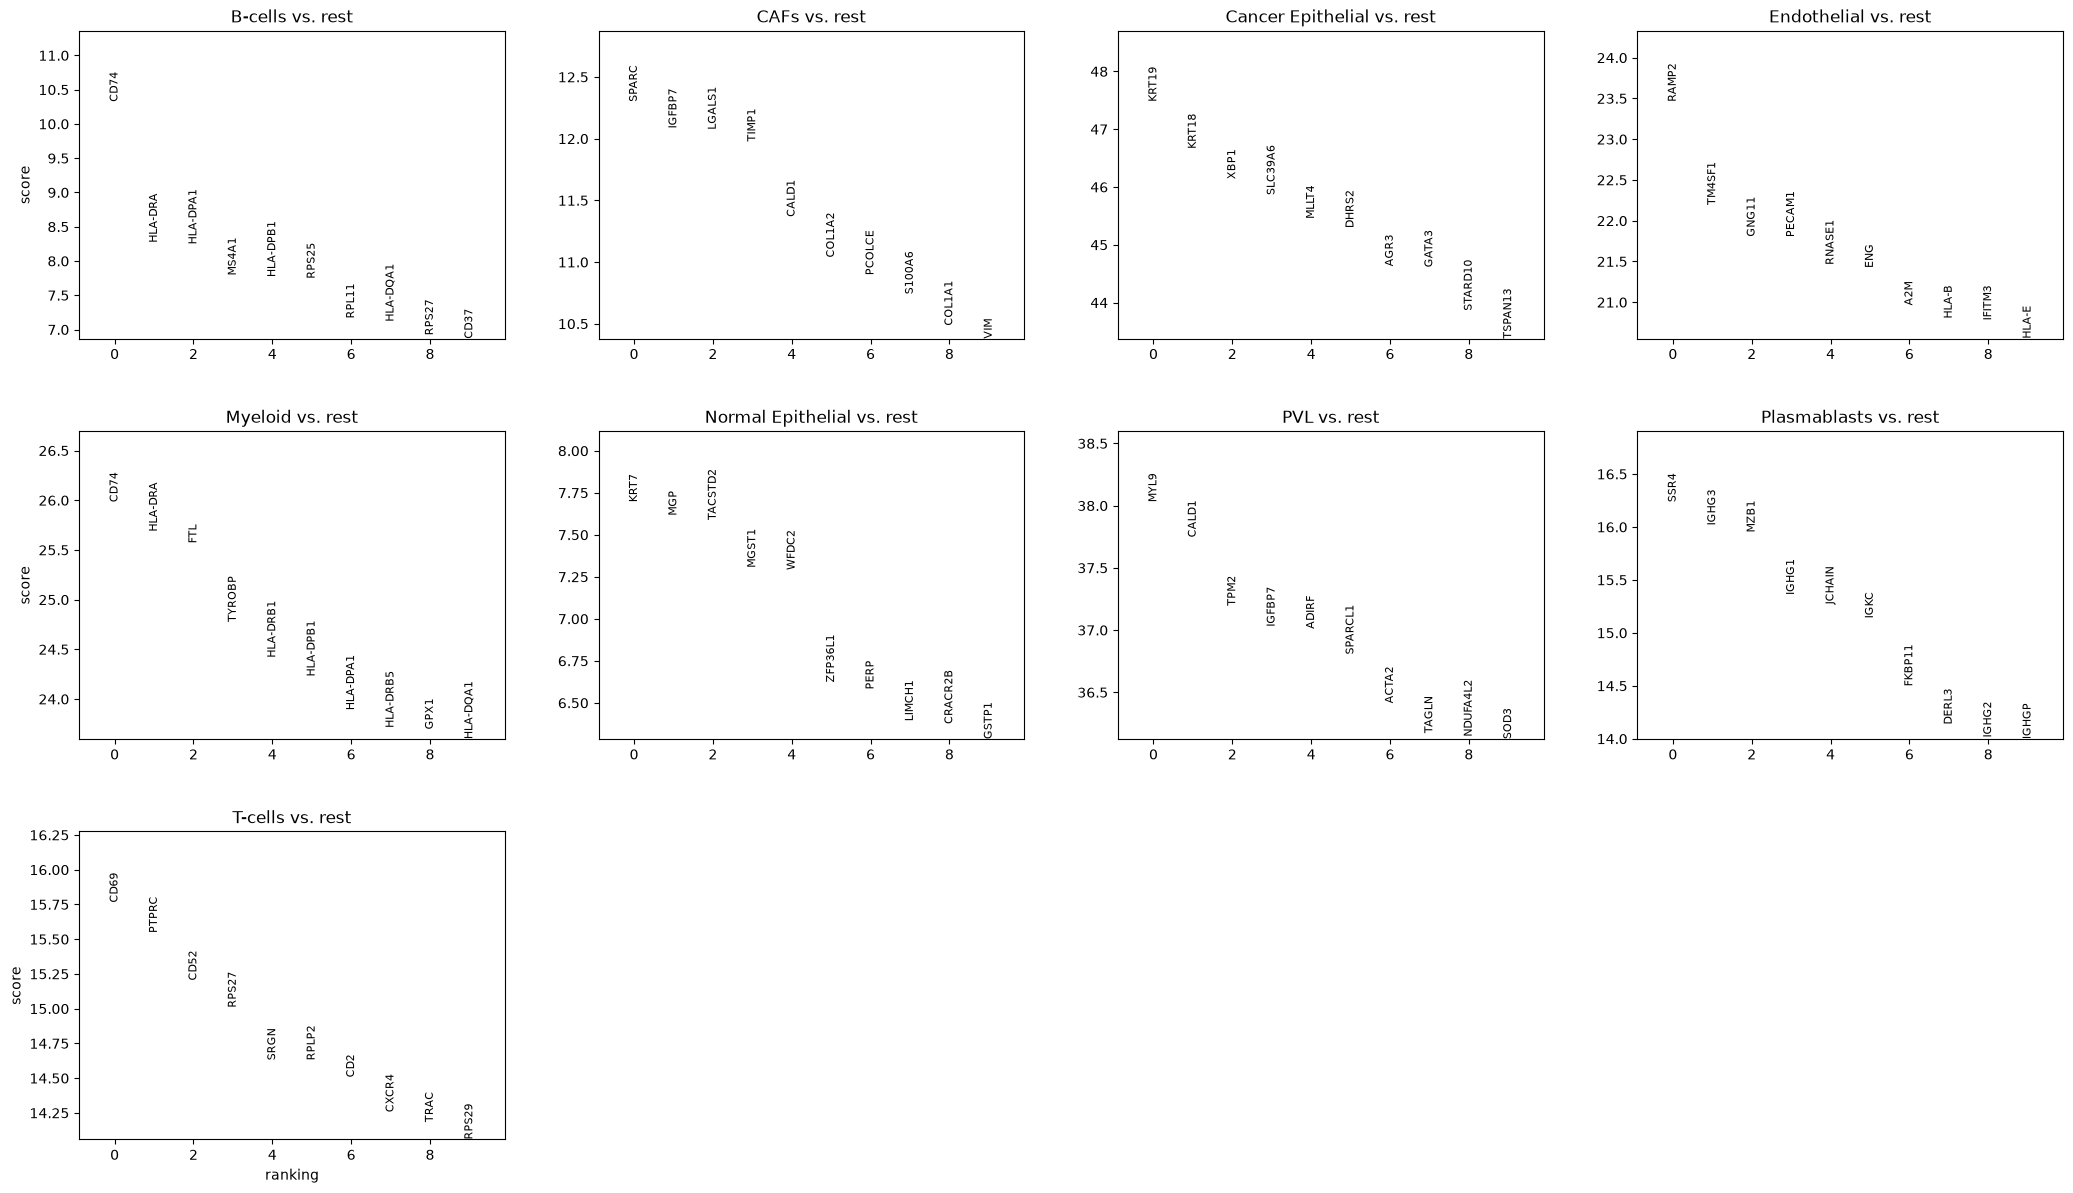

In [17]:
annotation_columns = ["celltype_major", "celltype_minor", "celltype_subset"]
annotation_level = "celltype_major"  # 本轮按作者大类检查marker

sc.tl.rank_genes_groups(
    adata_analysis,
    groupby=annotation_level,
    method="wilcoxon",
    use_raw=False,
    pts=True,
    corr_method="benjamini-hochberg",
    key_added="markers_author_major",
)
marker_table = sc.get.rank_genes_groups_df(adata_analysis, group=None, key="markers_author_major")
display(marker_table.groupby("group", observed=True).head(5))
sc.pl.rank_genes_groups(adata_analysis, key="markers_author_major", n_genes=10, sharey=False)


# 9. 使用作者注释, 检查表达合理性

## 9.1 查看聚类与作者标签的对应关系

保留作者的major、minor和subset三级标签。通过交叉表观察本次Leiden分群与作者注释的对应关系，细胞类型继续使用作者标签。

In [18]:
label_tables = {}
for label in annotation_columns:
    label_tables[label] = pd.crosstab(adata_analysis.obs["leiden"], adata_analysis.obs[label])
    print(label)
    display(label_tables[label])

celltype_major


celltype_major,B-cells,CAFs,Cancer Epithelial,Endothelial,Myeloid,Normal Epithelial,PVL,Plasmablasts,T-cells
leiden,,,,,,,,,
0,0,1,1,218,0,0,0,0,1
1,0,39,0,1,0,0,589,0,0
2,0,58,2,0,0,0,0,0,1
3,1,1,851,0,0,0,0,0,8
4,0,0,514,0,0,0,0,0,2
5,0,3,22,0,0,0,3,0,1
6,12,0,1,0,210,0,0,0,1
7,32,0,0,0,0,0,0,0,0
8,2,0,221,0,4,1,0,0,118


celltype_minor


celltype_minor,B cells Memory,CAFs MSC iCAF-like,CAFs myCAF-like,Cancer Basal SC,Cancer Cycling,Cancer Her2 SC,Cancer LumB SC,Cycling PVL,Cycling T-cells,Cycling_Myeloid,...,Mature Luminal,Monocyte,Myoepithelial,NK cells,NKT cells,PVL Differentiated,PVL Immature,Plasmablasts,T cells CD4+,T cells CD8+
leiden,,,,,,,,,,,,,,,,,,,,,
0,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,32,7,0,0,0,0,10,0,0,...,0,0,0,0,0,428,151,0,0,0
2,0,21,37,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,1,1,0,0,12,0,839,0,0,0,...,0,0,0,0,0,0,0,0,8,0
4,0,0,0,0,11,1,502,0,0,0,...,0,0,0,0,0,0,0,0,2,0
5,0,3,0,0,0,0,22,0,0,0,...,0,0,0,0,0,2,1,0,1,0
6,12,0,0,0,0,0,1,0,1,7,...,0,72,0,0,0,0,0,0,0,0
7,32,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,2,0,0,0,17,1,203,0,7,1,...,0,0,1,0,0,0,0,0,110,1


celltype_subset


celltype_subset,B cells Memory,CAFs MSC iCAF-like s1,CAFs MSC iCAF-like s2,CAFs Transitioning s3,CAFs myCAF like s4,CAFs myCAF like s5,Cancer Basal SC,Cancer Cycling,Cancer Her2 SC,Cancer LumB SC,...,T_cells_c1_CD4+_IL7R,T_cells_c2_CD4+_T-regs_FOXP3,T_cells_c3_CD4+_Tfh_CXCL13,T_cells_c4_CD8+_ZFP36,T_cells_c6_IFIT1,T_cells_c7_CD8+_IFNG,T_cells_c8_CD8+_LAG3,T_cells_c9_NK_cells_AREG,T_cells_c10_NKT_cells_FCGR3A,T_cells_c11_MKI67
leiden,,,,,,,,,,,,,,,,,,,,,
0,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
1,0,1,31,0,6,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,11,10,4,12,21,0,1,0,1,...,1,0,0,0,0,0,0,0,0,0
3,1,0,1,0,0,0,0,12,0,839,...,8,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,11,1,502,...,2,0,0,0,0,0,0,0,0,0
5,0,0,3,0,0,0,0,0,0,22,...,1,0,0,0,0,0,0,0,0,0
6,12,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
7,32,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,2,0,0,0,0,0,0,17,1,203,...,109,1,0,0,0,1,0,0,0,7


## 9.2 按作者注释展示marker表达

点图的每一行使用作者的celltype_major标签。下列marker组合是补充的表达检查面板，列上方的名称描述各组基因的检查用途。

点大小表示该作者注释群中检测到基因表达的细胞比例；颜色是按基因缩放后的群平均表达，用于比较同一基因在不同群中的表达。共享marker和低计数漏检都可能造成信号交叉，细胞标签沿用作者注释。

作者的celltype_minor和celltype_subset原样保留，后续可在目标谱系中使用。

当前对象中未找到的marker： []


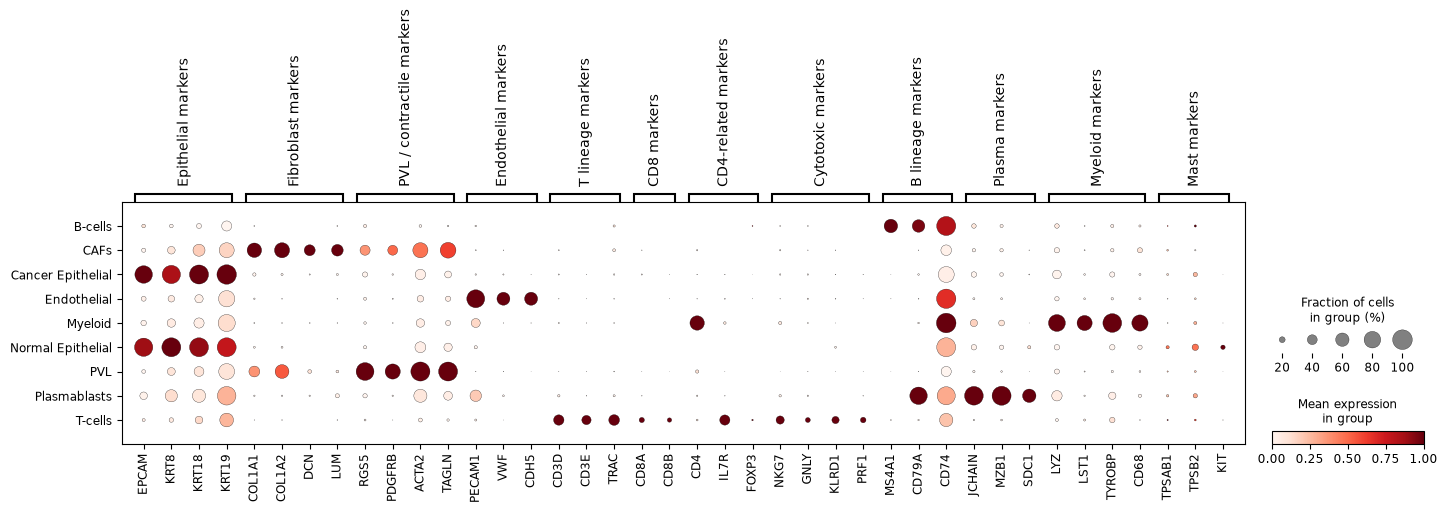

In [19]:
marker_panel = {
    "Epithelial markers": ["EPCAM", "KRT8", "KRT18", "KRT19"],
    "Fibroblast markers": ["COL1A1", "COL1A2", "DCN", "LUM"],
    "PVL / contractile markers": ["RGS5", "PDGFRB", "ACTA2", "TAGLN"],
    "Endothelial markers": ["PECAM1", "VWF", "CDH5"],
    "T lineage markers": ["CD3D", "CD3E", "TRAC"],
    "CD8 markers": ["CD8A", "CD8B"],
    "CD4-related markers": ["CD4", "IL7R", "FOXP3"],
    "Cytotoxic markers": ["NKG7", "GNLY", "KLRD1", "PRF1"],
    "B lineage markers": ["MS4A1", "CD79A", "CD74"],
    "Plasma markers": ["JCHAIN", "MZB1", "SDC1"],
    "Myeloid markers": ["LYZ", "LST1", "TYROBP", "CD68"],
    "Mast markers": ["TPSAB1", "TPSB2", "KIT"],
}
missing_markers = sorted({g for gs in marker_panel.values() for g in gs if g not in adata_analysis.var_names})
print("当前对象中未找到的marker：", missing_markers)
available_markers = {
    label: [g for g in genes if g in adata_analysis.var_names] for label, genes in marker_panel.items()
}
available_markers = {label: genes for label, genes in available_markers.items() if genes}
sc.pl.dotplot(
    adata_analysis,
    var_names=available_markers,
    groupby=annotation_level,
    use_raw=False,
    standard_scale="var",
)

# 10. 保留作者的注释并展示细胞组成

当前使用Wu 2021公开metadata中的celltype_major、celltype_minor和celltype_subset作为细胞注释。下面逐细胞核对这些标签与输入metadata一致，并记录来源。marker用于检查这些注释群的表达。

,orig.ident,subtype,celltype_major,celltype_minor,celltype_subset
CID4535_AAACCTGTCGCGGATC,CID4535,ER+,Endothelial,Endothelial ACKR1,Endothelial ACKR1
CID4535_AAAGCAAGTCCCGACA,CID4535,ER+,Endothelial,Endothelial ACKR1,Endothelial ACKR1
CID4535_AAGGAGCCAAGCCGTC,CID4535,ER+,Endothelial,Endothelial ACKR1,Endothelial ACKR1
CID4535_ACACCAACATCACCCT,CID4535,ER+,Endothelial,Endothelial ACKR1,Endothelial ACKR1
CID4535_ACGGCCATCCAGGGCT,CID4535,ER+,Endothelial,Endothelial ACKR1,Endothelial ACKR1


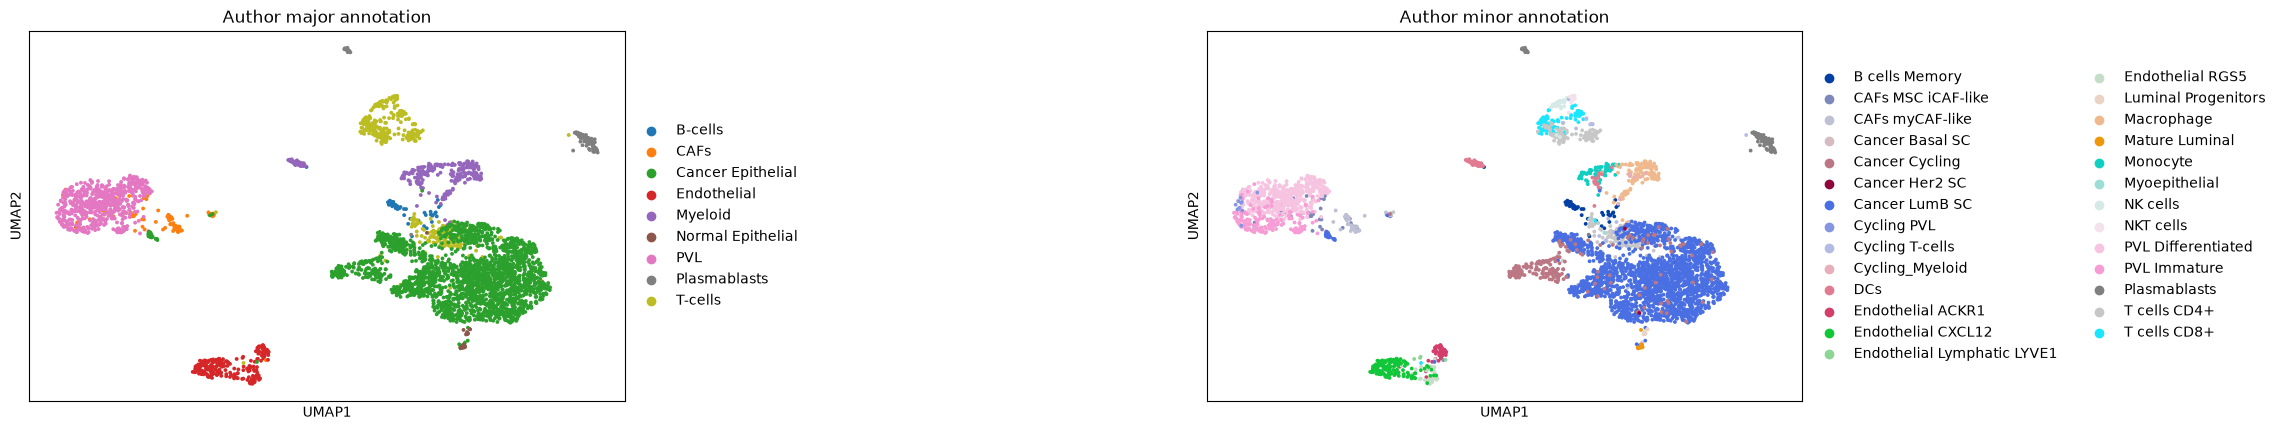

In [20]:
# 清除旧流程创建的占位标签；保留作者的原始注释
adata_analysis.obs.drop(columns=["celltype_manual"], errors="ignore", inplace=True)

author_labels = metadata.loc[adata_analysis.obs_names, annotation_columns]
assert not author_labels.isna().any().any(), "作者注释存在缺失，请核对输入metadata。"
assert adata_analysis.obs[annotation_columns].astype(str).equals(author_labels.astype(str))

annotation_table = adata_analysis.obs[["orig.ident", "subtype", *annotation_columns]].copy()
adata_analysis.uns["annotation_provenance"] = {
    "mode": "author_provided",
    "study": "Wu et al. 2021 / GSE176078",
    "metadata_file": str((DATA / "metadata.csv").relative_to(PROJECT_DIR)),
    "columns": annotation_columns,
}
display(annotation_table.head())
sc.pl.umap(
    adata_analysis,
    color=["celltype_major", "celltype_minor"],
    title=["Author major annotation", "Author minor annotation"],
    wspace=0.8,
)


下面按作者的大类标签统计细胞数量与比例，描述本次捕获细胞的组成。T-cells大类包含更细的T/NK相关标签，CD8 T细胞需要按细分标签统计。

,n_cells,fraction
celltype_major,,
Cancer Epithelial,2223,0.561222
PVL,592,0.149457
T-cells,396,0.099975
Myeloid,255,0.064378
Endothelial,219,0.055289
CAFs,102,0.025751
Plasmablasts,96,0.024236
B-cells,56,0.014138
Normal Epithelial,22,0.005554


<Axes: title={'center': 'Cell composition (author annotation)'}, xlabel='Number of cells', ylabel='Author cell type'>

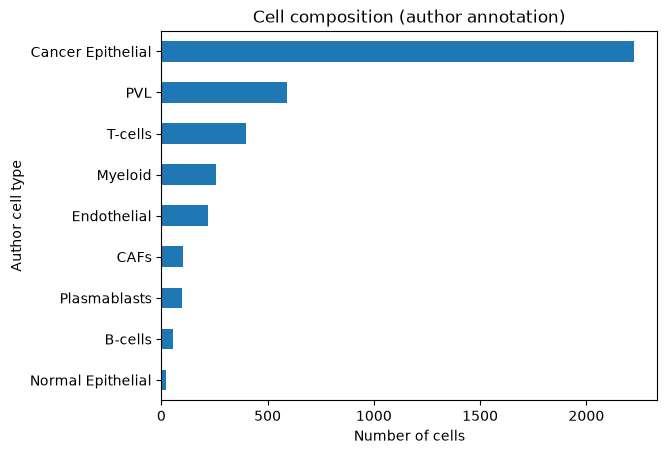

In [21]:
cell_composition_author = adata_analysis.obs["celltype_major"].value_counts().rename("n_cells").to_frame()
cell_composition_author["fraction"] = cell_composition_author["n_cells"] / adata_analysis.n_obs
display(cell_composition_author)
cell_composition_author["n_cells"].sort_values().plot.barh(
    xlabel="Number of cells", ylabel="Author cell type", title="Cell composition (author annotation)"
)


# 11. 保存对象、参数和分析结果

## 11.1 记录本轮分析设置


In [22]:
import json
from importlib.metadata import version

run_name = "CID4535_baseline_v1"  # 新一轮参数使用新的名称
RUN_DIR = PROJECT_DIR / "results" / run_name
OBJECT_DIR = PROJECT_DIR / "data" / "processed" / run_name
RUN_DIR.mkdir(parents=True, exist_ok=True)
OBJECT_DIR.mkdir(parents=True, exist_ok=True)

software_versions = {
    name: version(name)
    for name in [
        "scanpy",
        "anndata",
        "numpy",
        "pandas",
        "scipy",
        "matplotlib",
        "igraph",
        "umap-learn",
    ]
}
run_record = {
    "sample": "CID4535",
    "input_directory": str(DATA.relative_to(PROJECT_DIR)),
    "qc_params": qc_params,
    "actual_n_pcs_compute": n_pcs,
    "actual_n_pcs_neighbors": n_pcs_used,
    "actual_n_neighbors": n_neighbors_used,
    "hvg_flavor": "seurat",
    "n_highly_variable": int(adata_analysis.var["highly_variable"].sum()),
    "normalization_target_sum": 10000,
    "expression_for_markers": "log1p_normalized_counts",
    "leiden_resolution": float(adata_analysis.uns["leiden"]["params"]["resolution"]),
    "random_seed": 0,
    "umap_min_dist": 0.5,
    "marker_corr_method": "benjamini-hochberg",
    "marker_expression_fractions": True,
    "display_annotation_source": "author metadata celltype_major",
    "analysis_scope": "single-sample broad-lineage demonstration",
    "pca_scaling": "centered_without_unit_variance_scaling",
    "leiden_flavor": "igraph",
    "leiden_n_iterations": 2,
    "marker_method": "wilcoxon",
    "software_versions": software_versions,
    "annotation_mode": "author_provided",
    "annotation_columns": annotation_columns,
    "annotation_metadata_file": str((DATA / "metadata.csv").relative_to(PROJECT_DIR)),
    "marker_groupby": annotation_level,
    "marker_review_mode": "expression_consistency_check",
}
adata_analysis.uns["run_record_json"] = json.dumps(run_record, ensure_ascii=False)
(RUN_DIR / "parameters.json").write_text(json.dumps(run_record, ensure_ascii=False, indent=2), encoding="utf-8")
run_record


{'sample': 'CID4535',
 'input_directory': 'data/raw/wu2021_scrna_smoke/CID4535',
 'qc_params': {'min_genes': None,
  'max_genes': None,
  'min_counts': None,
  'max_counts': None,
  'max_pct_mt': None,
  'min_cells_per_gene': 1},
 'actual_n_pcs_compute': 50,
 'actual_n_pcs_neighbors': 30,
 'actual_n_neighbors': 15,
 'hvg_flavor': 'seurat',
 'n_highly_variable': 3000,
 'normalization_target_sum': 10000,
 'expression_for_markers': 'log1p_normalized_counts',
 'leiden_resolution': 0.5,
 'random_seed': 0,
 'umap_min_dist': 0.5,
 'marker_corr_method': 'benjamini-hochberg',
 'marker_expression_fractions': True,
 'display_annotation_source': 'author metadata celltype_major',
 'analysis_scope': 'single-sample broad-lineage demonstration',
 'pca_scaling': 'centered_without_unit_variance_scaling',
 'leiden_flavor': 'igraph',
 'leiden_n_iterations': 2,
 'marker_method': 'wilcoxon',
 'software_versions': {'scanpy': '1.12.4',
  'anndata': '0.13.3.post0',
  'numpy': '2.5.3',
  'pandas': '3.0.5',
  's

## 11.2 保存表格与AnnData对象

保存作者大类的marker排序、带细胞条码的作者三级注释，以及作者大类组成。Leiden与作者标签的交叉表作为对照保留。AnnData中的三级注释与输入metadata一致。

In [23]:
qc_record.to_csv(RUN_DIR / "cell_qc_record.csv")
filter_summary.to_csv(RUN_DIR / "filter_summary.csv")
composition_qc.to_csv(RUN_DIR / "composition_before_after_qc.csv")
marker_table.to_csv(RUN_DIR / "author_major_markers.csv", index=False)
annotation_table.to_csv(RUN_DIR / "author_cell_annotations.csv", index_label="barcode")
cell_composition_author.to_csv(RUN_DIR / "cell_composition_author.csv")
adata_analysis.var[["gene_symbol", "highly_variable"]].to_csv(RUN_DIR / "gene_features.csv")
for label, table in label_tables.items():
    table.to_csv(RUN_DIR / f"leiden_vs_{label}.csv")

adata_qc.write_h5ad(OBJECT_DIR / "qc_counts.h5ad", compression="gzip")
adata_analysis.write_h5ad(OBJECT_DIR / "single_cell_analysis.h5ad", compression="gzip")
print("结果目录：", RUN_DIR)
print("对象目录：", OBJECT_DIR)

结果目录： /Users/georicl/Documents/sc_sncell_github/results/CID4535_baseline_v1
对象目录： /Users/georicl/Documents/sc_sncell_github/data/processed/CID4535_baseline_v1


## 11.3 导出主要图形

主要图形保存为PDF和300 DPI的PNG。UMAP对照本次聚类与作者大类注释，marker点图按作者大类分组，细胞组成图使用作者标签。小提琴图与PCA图保留在notebook中，用于检查分析过程。

In [24]:
import matplotlib.pyplot as plt

sc.pl.scatter(adata_qc, x="total_counts", y="n_genes_by_counts", color="pct_counts_mt", show=False)
qc_figure = plt.gcf()
umap_figure = sc.pl.umap(
    adata_analysis,
    color=["leiden", "celltype_major"],
    title=["Leiden clusters", "Author annotation"],
    wspace=0.5,
    return_fig=True,
    show=False,
)
for name, figure in [("qc_counts_genes", qc_figure), ("umap_annotations", umap_figure)]:
    figure.savefig(RUN_DIR / f"{name}.pdf", bbox_inches="tight")
    figure.savefig(RUN_DIR / f"{name}.png", dpi=300, bbox_inches="tight")
    plt.close(figure)

dotplot = sc.pl.dotplot(
    adata_analysis,
    var_names=available_markers,
    groupby=annotation_level,
    use_raw=False,
    standard_scale="var",
    return_fig=True,
    show=False,
)
dotplot.savefig(RUN_DIR / "marker_dotplot_author_major.pdf", bbox_inches="tight")
dotplot.savefig(RUN_DIR / "marker_dotplot_author_major.png", dpi=300, bbox_inches="tight")
fig, ax = plt.subplots(figsize=(7, 4))
cell_composition_author["n_cells"].sort_values().plot.barh(ax=ax, color="#39749b")
ax.set(xlabel="Number of cells", ylabel="Author cell type", title="Cell composition (author annotation)")
for container in ax.containers:
    ax.bar_label(container, padding=3)
ax.set_xlim(0, cell_composition_author["n_cells"].max() * 1.15)
for extension in ["pdf", "png"]:
    fig.savefig(RUN_DIR / f"cell_composition_author.{extension}", bbox_inches="tight", dpi=300)
plt.close("all")